# Import Lib

In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report
import warnings
warnings.filterwarnings("ignore")

# Read Data

In [270]:
df = pd.read_csv("Titanic-Dataset .csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Data Exploring

In [271]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [272]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [273]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [274]:
df.shape

(891, 12)

In [275]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [276]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [277]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [278]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [279]:
(df["Age"].isnull().sum()/ len(df)) * 100

np.float64(19.865319865319865)

In [280]:
(df["Cabin"].isnull().sum()/ len(df)) * 100

np.float64(77.10437710437711)

In [281]:
df.duplicated().sum()

np.int64(0)

# EDA

In [282]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

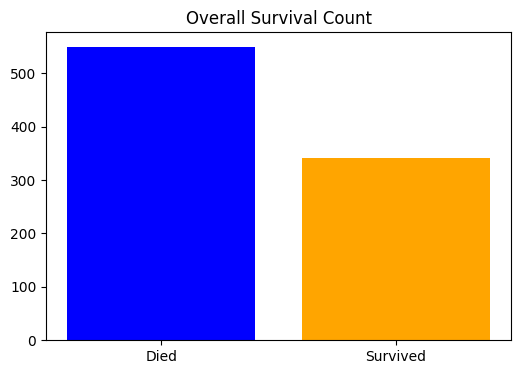

In [283]:

survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Died","Survived"], survival_counts.values,color=["blue", "orange"])
plt.title("Overall Survival Count")
plt.show()

In [284]:
gender_survival = df.groupby("Sex")["Survived"].mean()
gender_survival

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

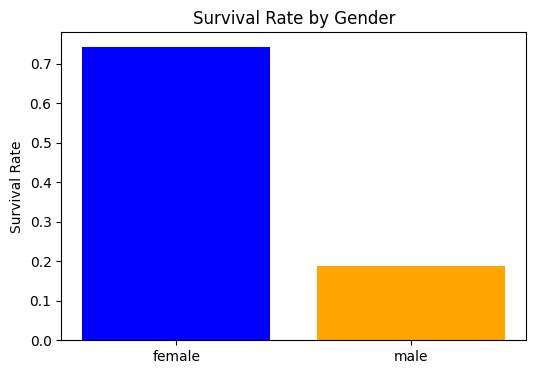

In [285]:
# Survival by Gender
gender_survival = df.groupby("Sex")["Survived"].mean()

plt.figure(figsize=(6,4))
plt.bar(gender_survival.index, gender_survival.values,color=["blue", "orange"])
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

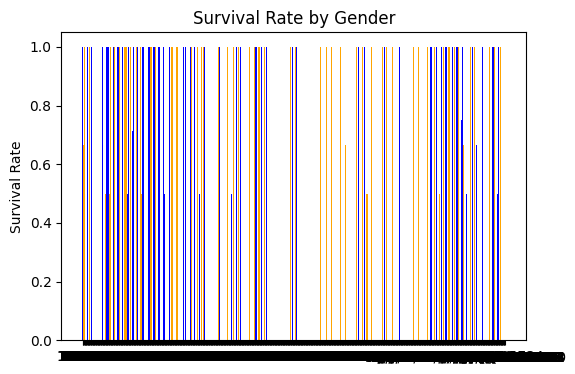

In [286]:
# Survival by Gender
gender_survival = df.groupby("Ticket")["Survived"].mean()

plt.figure(figsize=(6,4))
plt.bar(gender_survival.index, gender_survival.values,color=["blue", "orange"])
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

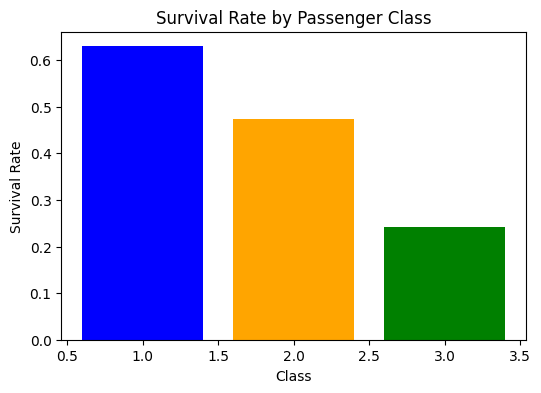

In [287]:
# Survival by Class
class_survival = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(6,4))
plt.bar(class_survival.index, class_survival.values,color=["blue", "orange","green"])
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Class")
plt.ylabel("Survival Rate")
plt.show()

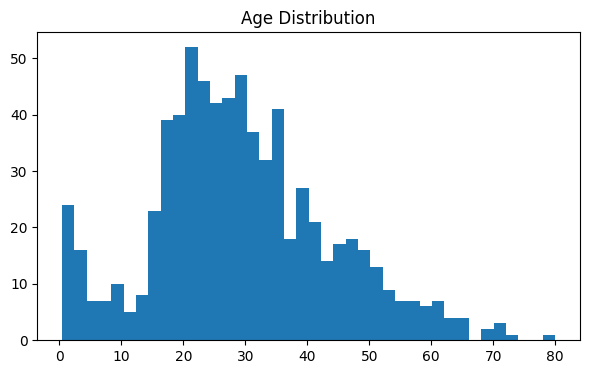

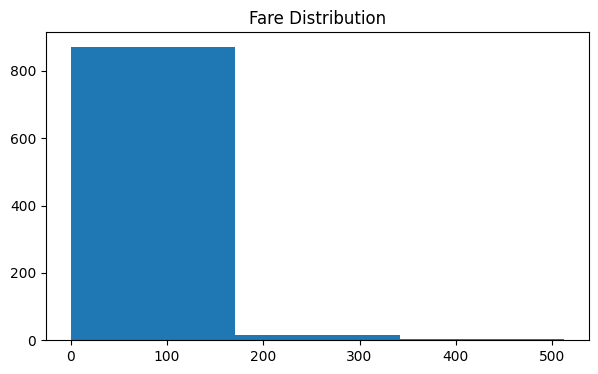

In [288]:
# Age distribution
plt.figure(figsize=(7,4))
plt.hist(df["Age"],bins= 40)
plt.title("Age Distribution")
plt.show()

# Fare distribution
plt.figure(figsize=(7,4))
plt.hist(df["Fare"], bins=3)
plt.title("Fare Distribution")
plt.show()


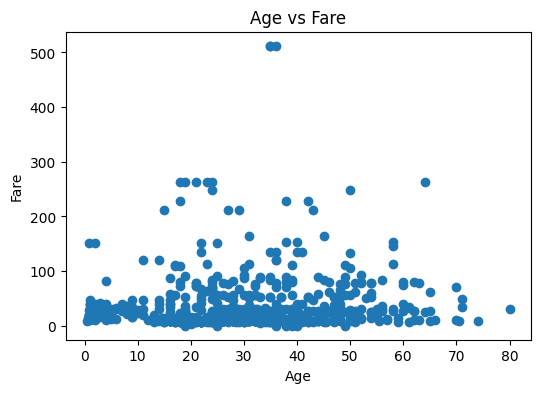

In [289]:

plt.figure(figsize=(6,4))
plt.scatter(df["Age"], df["Fare"])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

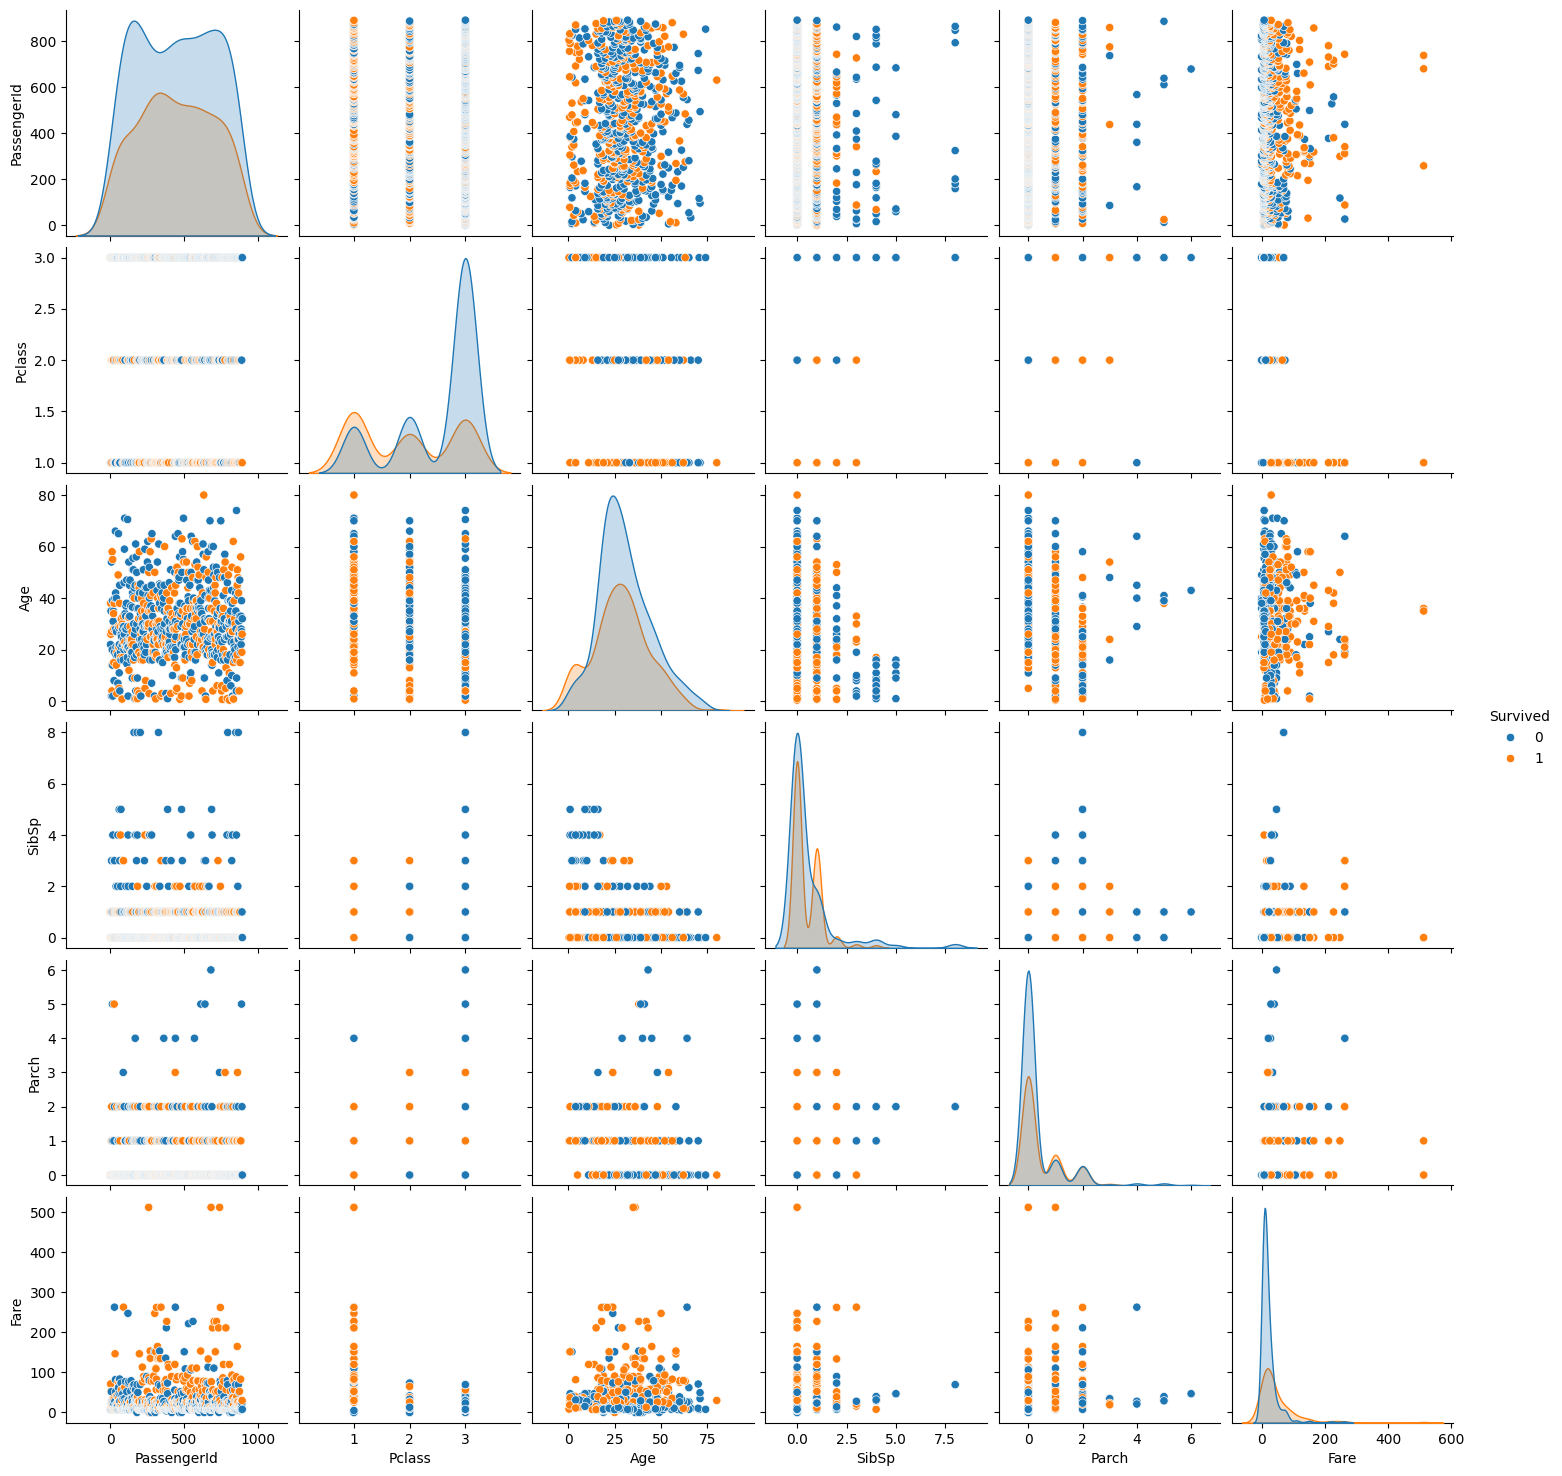

In [290]:
sns.pairplot(df,hue='Survived')
plt.show()


In [291]:
corr = df.corr(numeric_only = True)["Survived"].sort_values(ascending = False)
corr

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

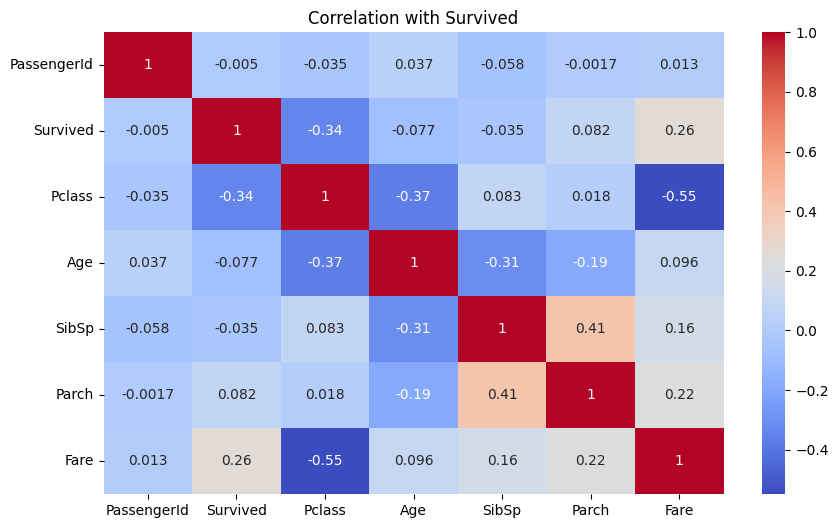

In [292]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation with Survived")
plt.show()

## Outliers Detection

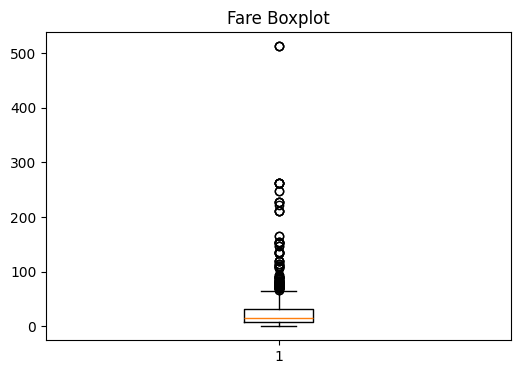

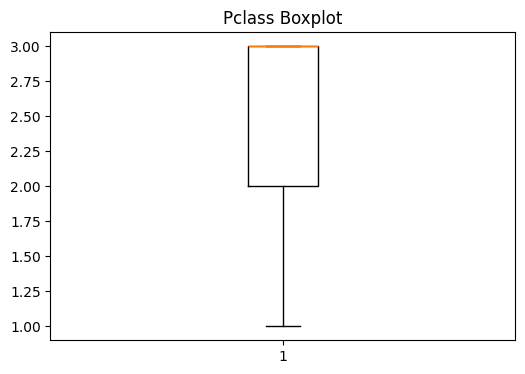

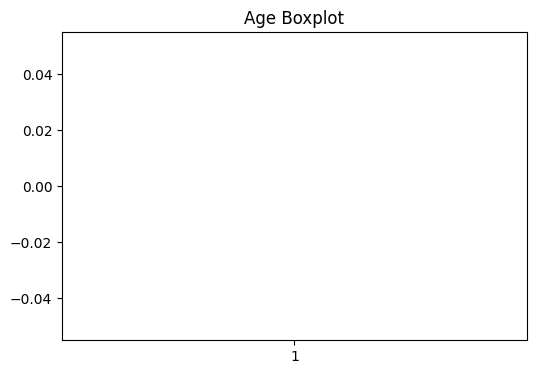

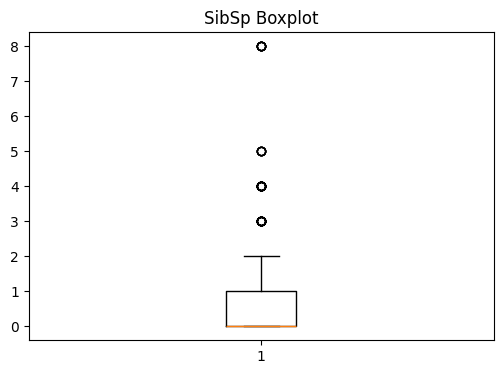

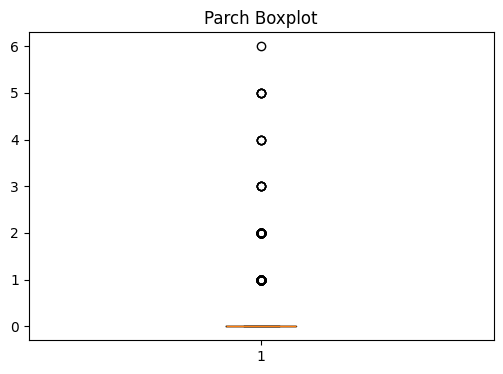

In [293]:

plt.figure(figsize=(6,4))
plt.boxplot(df["Fare"])
plt.title("Fare Boxplot")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(df["Pclass"])
plt.title("Pclass Boxplot")
plt.show()


plt.figure(figsize=(6,4))
plt.boxplot(df["Age"])
plt.title("Age Boxplot")
plt.show()


plt.figure(figsize=(6,4))
plt.boxplot(df["SibSp"])
plt.title("SibSp Boxplot")
plt.show()


plt.figure(figsize=(6,4))
plt.boxplot(df["Parch"])
plt.title("Parch Boxplot")
plt.show()




In [294]:
# IQR Method
outliers = ["Fare","Age","SibSp","Parch"]
for outlier in outliers:
    Q1 = df[outlier].quantile(0.25)
    Q3 = df[outlier].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"\nOutlier Boundaries for {outlier}:")
    print("Lower:", lower)
    print("Upper:", upper)

    outliers = df[(df[outlier] < lower) | (df[outlier] > upper)]
    print( "Total number of outtliers: ",len(outliers))


Outlier Boundaries for Fare:
Lower: -26.724
Upper: 65.6344
Total number of outtliers:  116

Outlier Boundaries for Age:
Lower: -6.6875
Upper: 64.8125
Total number of outtliers:  11

Outlier Boundaries for SibSp:
Lower: -1.5
Upper: 2.5
Total number of outtliers:  46

Outlier Boundaries for Parch:
Lower: 0.0
Upper: 0.0
Total number of outtliers:  213


# Data Cleaning

In [295]:
# Fixing the nulls
df["Age"].fillna(df["Age"].mean(),inplace = True)
df.drop(columns = ["Cabin"],inplace = True)
df["Embarked"].fillna("S",inplace = True)
df["Fare"].fillna(df["Fare"].median(),inplace = True)

print("Missing After Cleaning:")
df.isnull().sum()

Missing After Cleaning:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [296]:
# outliers handling
# Fare
df["Fare"] = np.log1p(df["Fare"])

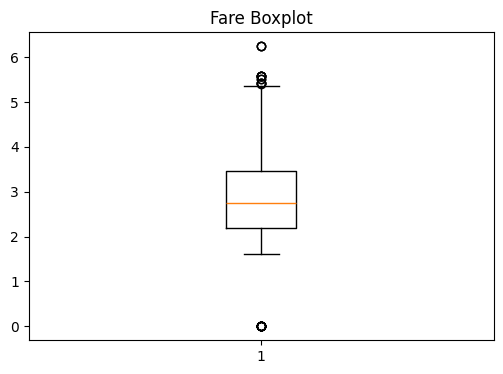

In [297]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Fare"])
plt.title("Fare Boxplot")
plt.show()

In [298]:
nag = df["Age"][df["Age"] < 0].sum()
nag

np.float64(0.0)

In [299]:
# drop unuseful features
df.drop(columns= ["PassengerId","Name","Ticket"],inplace=True)

In [300]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,2.110213,S
1,1,1,female,38.000000,1,0,4.280593,C
2,1,3,female,26.000000,0,0,2.188856,S
3,1,1,female,35.000000,1,0,3.990834,S
4,0,3,male,35.000000,0,0,2.202765,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,2.639057,S
887,1,1,female,19.000000,0,0,3.433987,S
888,0,3,female,29.699118,1,2,3.196630,S
889,1,1,male,26.000000,0,0,3.433987,C


In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [302]:
df["Sex"].unique

<bound method Series.unique of 0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object>

In [303]:
df["Embarked"].nunique()

3

In [304]:
df["Sex"] = df["Sex"].str.lower().map({"female" : 1,"male":0 })
df["Embarked"] = df["Embarked"].str.lower().map({"s": 1,"c": 0, "q": 2})

# Feature Eng

In [305]:
df["Family_size"] = df["SibSp"] + df["Parch"] + 1
df.drop(columns=["SibSp","Parch"],inplace = True)

In [306]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    float64
 4   Fare         891 non-null    float64
 5   Embarked     891 non-null    int64  
 6   Family_size  891 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


# Data Spliting

In [307]:

x = df.drop(columns=["Survived"])
y = df["Survived"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=1
)

In [308]:
x_train.shape

(712, 6)

In [309]:
x_test.shape

(179, 6)

In [310]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Models Building

In [311]:
# Logistic
lr = LogisticRegression()
lr.fit(x_train_scaled, y_train)
y_pred = lr.predict(x_test_scaled)
print("Accuracy Score with Logistic Regression:",accuracy_score(y_test,y_pred))
print("Classification Report with Logistic Regression:",classification_report(y_test,y_pred))

Accuracy Score with Logistic Regression: 0.8100558659217877
Classification Report with Logistic Regression:               precision    recall  f1-score   support

           0       0.83      0.85      0.84       106
           1       0.77      0.75      0.76        73

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



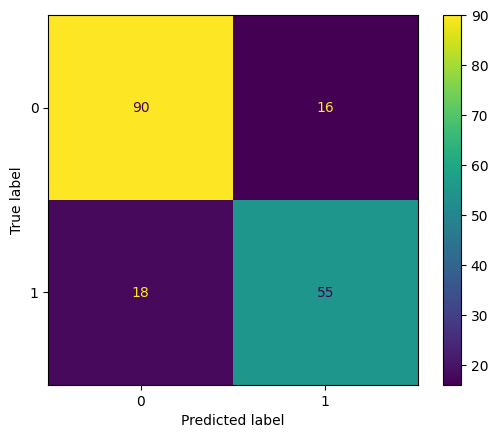

In [312]:
con = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred))
con.plot()
plt.show()

In [313]:

rf = RandomForestClassifier()
rf.fit(x_train_scaled, y_train)
y_pred_rf = rf.predict(x_test_scaled)
print("Accuracy Score with Random Forest",accuracy_score(y_test,y_pred_rf))
print("Classification Report with Random Forest :",classification_report(y_test,y_pred_rf))


Accuracy Score with Random Forest 0.7597765363128491
Classification Report with Random Forest :               precision    recall  f1-score   support

           0       0.75      0.89      0.81       106
           1       0.78      0.58      0.66        73

    accuracy                           0.76       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.76      0.75       179



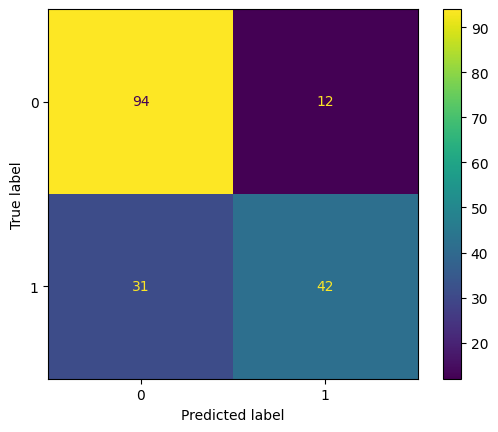

In [314]:
con2 = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_rf))
con2.plot()
plt.show()

In [316]:
import joblib
artifacts = {
    "model": lr,
    "scaler": scaler
   
     
}
joblib.dump(artifacts, "model.pkl")
print("Model saved successfully as model.pkl")


Model saved successfully as model.pkl
